# MEG Brain Signal Classification — Classical ML
**Deep Learning Project (INFOMDLR)**  
Goal: classify MEG recordings into 4 brain states — `rest`, `task_motor`, `task_story_math`, `task_working_memory`  
Tasks covered: **Intra-subject** and **Cross-subject** classification

### Why Classical ML?
Each MEG recording is a single sample of shape **(248 sensors × 35624 timepoints)**. With very few
files per split (typically ~16 for intra train), deep networks trivially overfit — train accuracy
reaches 100% while test stays at chance (25%).

Classical ML models generalise well on small datasets because they operate on **hand-crafted
statistical features** that encode domain knowledge rather than learning features from scratch.
We extract per-sensor statistics (mean, std, min, max) and frequency-band power, then compare
three models: **SVM**, **Random Forest**, and **LDA**.

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

np.random.seed(42)

CLASSES     = ["rest", "task_motor", "task_story_math", "task_working_memory"]
CLASS_NAMES = ["rest", "motor", "math", "memory"]
print("Imports OK")

Imports OK


## 2. Data Loading

In [2]:
def get_dataset_name(filepath):
    filename = filepath.replace("\\", "/").split("/")[-1]
    parts = filename.split("_")[:-1]   # drop the trailing chunk number
    return "_".join(parts)


def load_split(folder):
    """
    Load all .h5 files from a folder.
    Returns X: (N, 248, T), y: (N,)
    """
    X, y = [], []
    for file_name in sorted(os.listdir(folder)):
        if not file_name.endswith(".h5"):
            continue
        label = next((i for i, c in enumerate(CLASSES)
                      if file_name.startswith(c)), None)
        if label is None:
            print(f"  Skipping unrecognised file: {file_name}")
            continue
        filepath = os.path.join(folder, file_name)
        with h5py.File(filepath, "r") as f:
            key    = list(f.keys())[0]   # always take the first (and only) key
            matrix = f[key][()]
        X.append(matrix)
        y.append(label)
    X = np.array(X, dtype=np.float32)   # (N, 248, T)
    y = np.array(y)
    print(f"  Loaded {len(y)} files from {folder}  |  shape: {X.shape}")
    print(f"  Label counts: { {CLASS_NAMES[i]: int((y==i).sum()) for i in range(4)} }")
    return X, y


print("Loading intra splits...")
X_intra_train, y_intra_train = load_split("Final Project data/Intra/train")
X_intra_test,  y_intra_test  = load_split("Final Project data/Intra/test")

print("\nLoading cross splits...")
X_cross_train, y_cross_train = load_split("Final Project data/Cross/train")
X_cross_test1, y_cross_test1 = load_split("Final Project data/Cross/test1")
X_cross_test2, y_cross_test2 = load_split("Final Project data/Cross/test2")
X_cross_test3, y_cross_test3 = load_split("Final Project data/Cross/test3")

Loading intra splits...
  Loaded 32 files from Final Project data/Intra/train  |  shape: (32, 248, 35624)
  Label counts: {'rest': 8, 'motor': 8, 'math': 8, 'memory': 8}
  Loaded 8 files from Final Project data/Intra/test  |  shape: (8, 248, 35624)
  Label counts: {'rest': 2, 'motor': 2, 'math': 2, 'memory': 2}

Loading cross splits...
  Loaded 64 files from Final Project data/Cross/train  |  shape: (64, 248, 35624)
  Label counts: {'rest': 16, 'motor': 16, 'math': 16, 'memory': 16}
  Loaded 16 files from Final Project data/Cross/test1  |  shape: (16, 248, 35624)
  Label counts: {'rest': 4, 'motor': 4, 'math': 4, 'memory': 4}
  Loaded 16 files from Final Project data/Cross/test2  |  shape: (16, 248, 35624)
  Label counts: {'rest': 4, 'motor': 4, 'math': 4, 'memory': 4}
  Loaded 16 files from Final Project data/Cross/test3  |  shape: (16, 248, 35624)
  Label counts: {'rest': 4, 'motor': 4, 'math': 4, 'memory': 4}


## 3. Feature Extraction

Each raw sample is `(248 sensors × 35624 timepoints)`. We reduce this to a compact
feature vector per sample using per-sensor statistics and frequency-band energy.

| Feature group | Description | Size |
|---|---|---|
| Mean | Average signal per sensor | 248 |
| Std | Signal variability per sensor | 248 |
| Min / Max | Extreme values per sensor | 248 + 248 |
| Low-band energy | Mean absolute value, first 10% of time | 248 |
| High-band energy | Mean absolute value, last 10% of time | 248 |
| Peak-to-peak | Max - Min per sensor | 248 |

**Total: 1736 features per sample.**  
PCA then reduces this to a manageable number of components before classification.

In [3]:
def extract_features(X):
    """
    Extract statistical and frequency-band features per sensor.
    Input:  X of shape (N, 248, T)
    Output: feature matrix of shape (N, 1736)
    """
    T = X.shape[2]
    band = T // 10   # 10% of timepoints for band energy

    feats = [
        np.mean(X, axis=2),                             # mean per sensor
        np.std(X, axis=2),                              # std per sensor
        np.min(X, axis=2),                              # min per sensor
        np.max(X, axis=2),                              # max per sensor
        np.mean(np.abs(X[:, :, :band]), axis=2),        # low-band energy
        np.mean(np.abs(X[:, :, -band:]), axis=2),       # high-band energy
        np.max(X, axis=2) - np.min(X, axis=2),          # peak-to-peak range
    ]
    return np.concatenate(feats, axis=1).astype(np.float32)


print("Extracting features...")
F_intra_train = extract_features(X_intra_train)
F_intra_test  = extract_features(X_intra_test)
F_cross_train = extract_features(X_cross_train)
F_cross_test1 = extract_features(X_cross_test1)
F_cross_test2 = extract_features(X_cross_test2)
F_cross_test3 = extract_features(X_cross_test3)

print(f"Feature vector shape per sample: {F_intra_train.shape[1]}")
print(f"Intra train: {F_intra_train.shape}  |  test: {F_intra_test.shape}")
print(f"Cross train: {F_cross_train.shape}  |  test1: {F_cross_test1.shape}")

Extracting features...
Feature vector shape per sample: 1736
Intra train: (32, 1736)  |  test: (8, 1736)
Cross train: (64, 1736)  |  test1: (16, 1736)


## 4. Model Definitions

Each model is a `sklearn` Pipeline with three stages:
1. **StandardScaler** — z-score each feature across the training set
2. **PCA** — reduce dimensionality; with very few samples we cap components at `min(n_samples-1, 50)`
3. **Classifier** — SVM, Random Forest, or LDA

PCA is essential here: 1736 features >> ~16 samples means any classifier without dimensionality
reduction will overfit immediately.

In [4]:
def make_pipelines(n_samples):
    """
    Build three classifier pipelines.
    n_samples: number of training samples — used to cap PCA components.
    """
    # Cap PCA components so we never exceed n_samples - 1
    n_components = min(n_samples - 1, 50)
    print(f"PCA components: {n_components}  (capped to min(n_train-1, 50))")

    pipelines = {
        "SVM (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("pca",    PCA(n_components=n_components)),
            ("clf",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("pca",    PCA(n_components=n_components)),
            ("clf",    RandomForestClassifier(n_estimators=500, random_state=42))
        ]),
        "LDA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca",    PCA(n_components=n_components)),
            ("clf",    LinearDiscriminantAnalysis())
        ]),
    }
    return pipelines


print("Pipelines defined.")

Pipelines defined.


## 5. Evaluation Utility

In [5]:
def evaluate(name, clf, X_test, y_test):
    preds = clf.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    print(f"\n{'='*55}")
    print(f"{name}  —  accuracy: {acc*100:.1f}%")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.show()
    return acc


print("Evaluation utility defined.")

Evaluation utility defined.


## 6. Intra-Subject Classification
Train and test on recordings from the **same subjects**.  
Easier task — the model generalises across time, not across people.

=== INTRA-SUBJECT ===
PCA components: 31  (capped to min(n_train-1, 50))

SVM (RBF) — Intra  —  accuracy: 87.5%
              precision    recall  f1-score   support

        rest       0.67      1.00      0.80         2
       motor       1.00      0.50      0.67         2
        math       1.00      1.00      1.00         2
      memory       1.00      1.00      1.00         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8



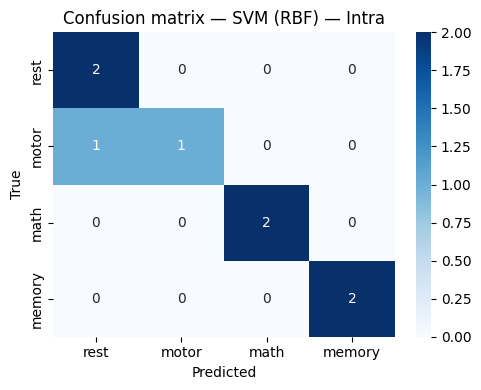


Random Forest — Intra  —  accuracy: 87.5%
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         2
       motor       1.00      0.50      0.67         2
        math       0.67      1.00      0.80         2
      memory       1.00      1.00      1.00         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8



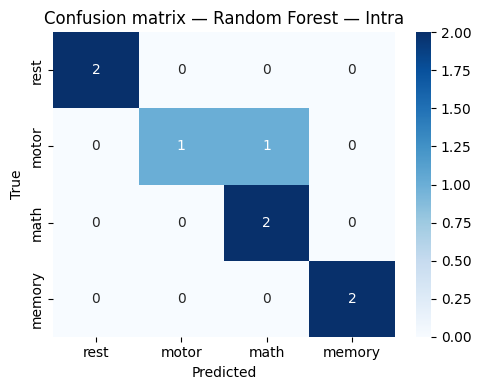


LDA — Intra  —  accuracy: 87.5%
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         2
       motor       1.00      1.00      1.00         2
        math       0.67      1.00      0.80         2
      memory       1.00      0.50      0.67         2

    accuracy                           0.88         8
   macro avg       0.92      0.88      0.87         8
weighted avg       0.92      0.88      0.87         8



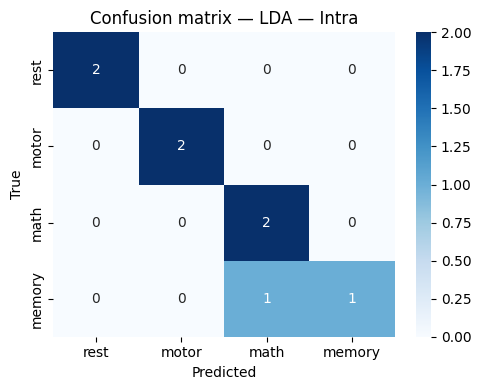

In [6]:
print("=== INTRA-SUBJECT ===")
intra_pipelines  = make_pipelines(len(y_intra_train))
intra_accuracies = {}

for name, clf in intra_pipelines.items():
    clf.fit(F_intra_train, y_intra_train)
    acc = evaluate(f"{name} — Intra", clf, F_intra_test, y_intra_test)
    intra_accuracies[name] = acc

## 7. Cross-Subject Classification
Train on one group of subjects, test on **three unseen subject groups**.  
Harder task — the model must generalise across individual brains.

=== CROSS-SUBJECT ===
PCA components: 50  (capped to min(n_train-1, 50))

SVM (RBF) — Cross (test1)  —  accuracy: 56.2%
              precision    recall  f1-score   support

        rest       1.00      0.75      0.86         4
       motor       0.00      0.00      0.00         4
        math       0.50      1.00      0.67         4
      memory       0.67      0.50      0.57         4

    accuracy                           0.56        16
   macro avg       0.54      0.56      0.52        16
weighted avg       0.54      0.56      0.52        16



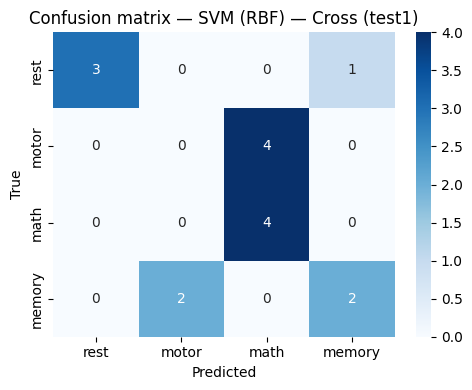


Random Forest — Cross (test1)  —  accuracy: 62.5%
              precision    recall  f1-score   support

        rest       0.00      0.00      0.00         4
       motor       0.57      1.00      0.73         4
        math       0.80      1.00      0.89         4
      memory       0.50      0.50      0.50         4

    accuracy                           0.62        16
   macro avg       0.47      0.62      0.53        16
weighted avg       0.47      0.62      0.53        16



c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

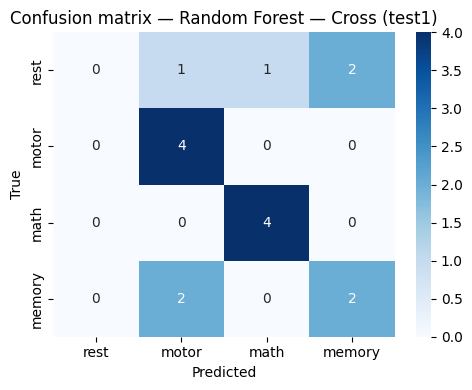


LDA — Cross (test1)  —  accuracy: 62.5%
              precision    recall  f1-score   support

        rest       0.00      0.00      0.00         4
       motor       1.00      0.75      0.86         4
        math       1.00      1.00      1.00         4
      memory       0.43      0.75      0.55         4

    accuracy                           0.62        16
   macro avg       0.61      0.62      0.60        16
weighted avg       0.61      0.62      0.60        16



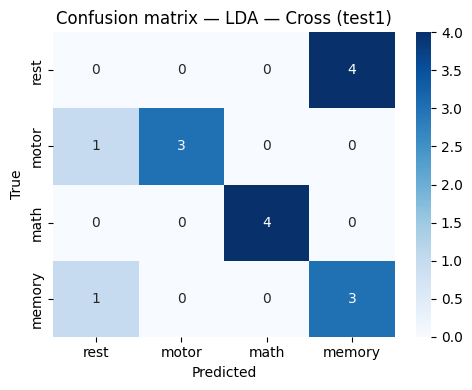


SVM (RBF) — Cross (test2)  —  accuracy: 43.8%
              precision    recall  f1-score   support

        rest       1.00      0.75      0.86         4
       motor       0.33      1.00      0.50         4
        math       0.00      0.00      0.00         4
      memory       0.00      0.00      0.00         4

    accuracy                           0.44        16
   macro avg       0.33      0.44      0.34        16
weighted avg       0.33      0.44      0.34        16



c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

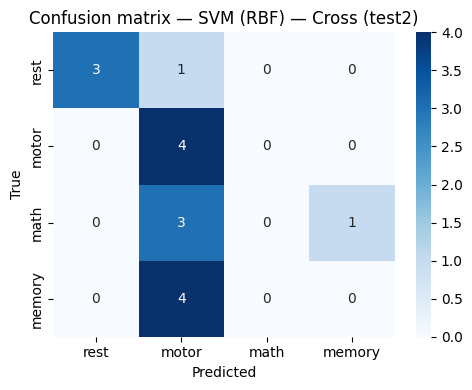


Random Forest — Cross (test2)  —  accuracy: 37.5%
              precision    recall  f1-score   support

        rest       0.50      0.75      0.60         4
       motor       0.43      0.75      0.55         4
        math       0.00      0.00      0.00         4
      memory       0.00      0.00      0.00         4

    accuracy                           0.38        16
   macro avg       0.23      0.38      0.29        16
weighted avg       0.23      0.38      0.29        16



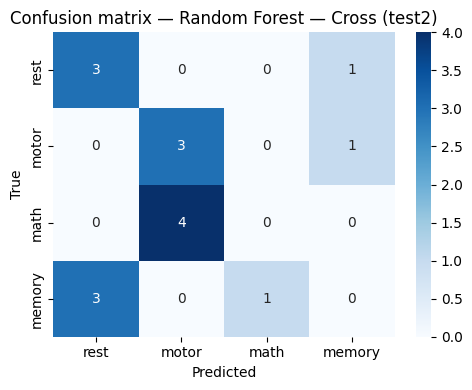


LDA — Cross (test2)  —  accuracy: 0.0%
              precision    recall  f1-score   support

        rest       0.00      0.00      0.00       4.0
       motor       0.00      0.00      0.00       4.0
        math       0.00      0.00      0.00       4.0
      memory       0.00      0.00      0.00       4.0

    accuracy                           0.00      16.0
   macro avg       0.00      0.00      0.00      16.0
weighted avg       0.00      0.00      0.00      16.0



c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dmath\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

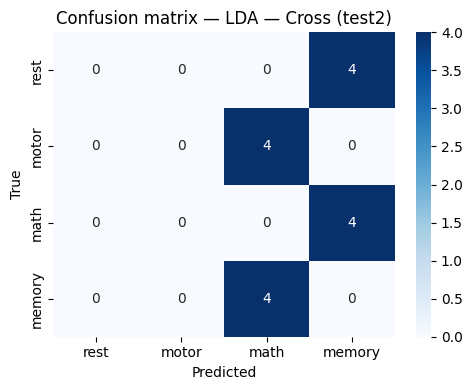


SVM (RBF) — Cross (test3)  —  accuracy: 75.0%
              precision    recall  f1-score   support

        rest       1.00      0.75      0.86         4
       motor       0.50      1.00      0.67         4
        math       1.00      0.50      0.67         4
      memory       1.00      0.75      0.86         4

    accuracy                           0.75        16
   macro avg       0.88      0.75      0.76        16
weighted avg       0.88      0.75      0.76        16



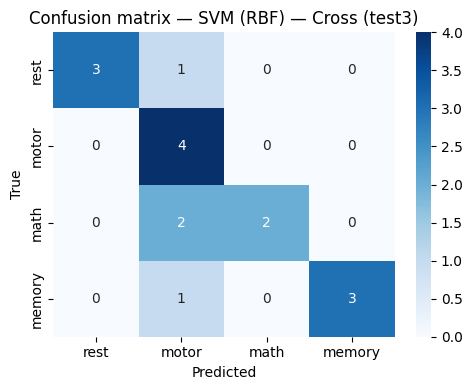


Random Forest — Cross (test3)  —  accuracy: 62.5%
              precision    recall  f1-score   support

        rest       0.57      1.00      0.73         4
       motor       0.67      1.00      0.80         4
        math       1.00      0.25      0.40         4
      memory       0.50      0.25      0.33         4

    accuracy                           0.62        16
   macro avg       0.68      0.62      0.57        16
weighted avg       0.68      0.62      0.57        16



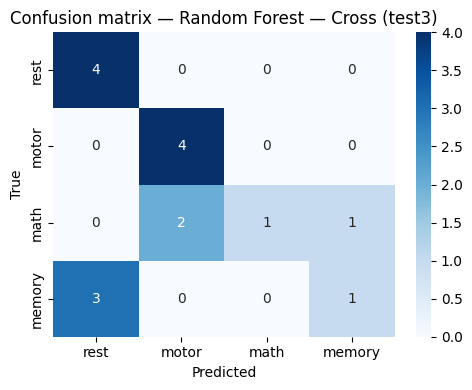


LDA — Cross (test3)  —  accuracy: 87.5%
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         4
       motor       1.00      1.00      1.00         4
        math       1.00      0.50      0.67         4
      memory       0.67      1.00      0.80         4

    accuracy                           0.88        16
   macro avg       0.92      0.88      0.87        16
weighted avg       0.92      0.88      0.87        16



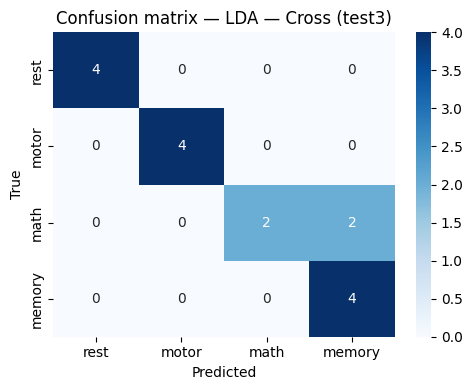

In [7]:
print("=== CROSS-SUBJECT ===")
cross_pipelines = make_pipelines(len(y_cross_train))

# Fit once on cross train
for name, clf in cross_pipelines.items():
    clf.fit(F_cross_train, y_cross_train)

cross_accuracies = {name: [] for name in cross_pipelines}

for test_name, F_test, y_test in [
    ("test1", F_cross_test1, y_cross_test1),
    ("test2", F_cross_test2, y_cross_test2),
    ("test3", F_cross_test3, y_cross_test3),
]:
    for name, clf in cross_pipelines.items():
        acc = evaluate(f"{name} — Cross ({test_name})", clf, F_test, y_test)
        cross_accuracies[name].append(acc)

## 8. Summary


SUMMARY
Model                   Intra    Cross avg
------------------------------------------
SVM (RBF)               87.5%        58.3%
Random Forest           87.5%        54.2%
LDA                     87.5%        50.0%
------------------------------------------
Chance baseline         25.0%        25.0%


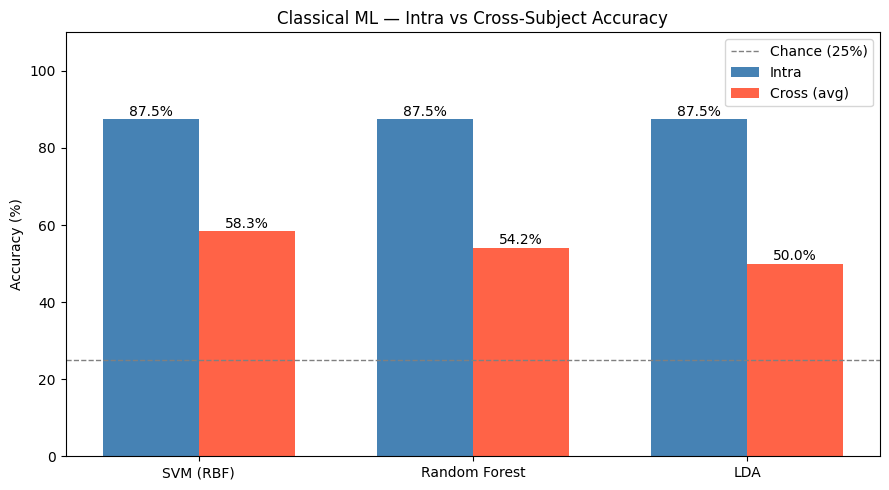

In [8]:
print("\n" + "="*55)
print("SUMMARY")
print("="*55)
print(f"{'Model':<20} {'Intra':>8} {'Cross avg':>12}")
print("-"*42)
for name in intra_pipelines:
    intra_acc = intra_accuracies[name]
    cross_avg = np.mean(cross_accuracies[name])
    print(f"{name:<20} {intra_acc*100:>7.1f}%  {cross_avg*100:>10.1f}%")
print("-"*42)
print(f"{'Chance baseline':<20} {'25.0%':>8} {'25.0%':>12}")

# Bar chart
model_names = list(intra_pipelines.keys())
intra_vals  = [intra_accuracies[n] * 100 for n in model_names]
cross_vals  = [np.mean(cross_accuracies[n]) * 100 for n in model_names]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, intra_vals, w, label="Intra",       color="steelblue")
bars2 = ax.bar(x + w/2, cross_vals, w, label="Cross (avg)", color="tomato")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", fontsize=10)

ax.axhline(25, color="gray", linestyle="--", linewidth=1, label="Chance (25%)")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title("Classical ML — Intra vs Cross-Subject Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Cross-Subject: Per-Test-Set Breakdown

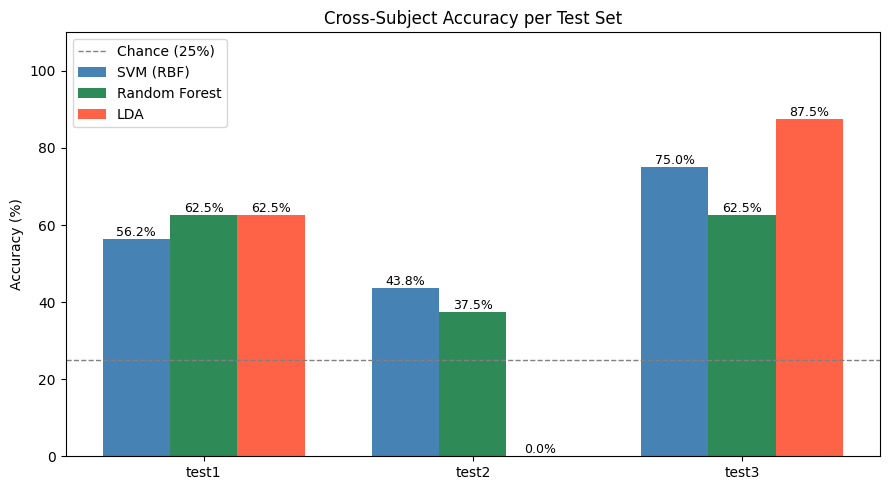

In [9]:
test_labels = ["test1", "test2", "test3"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(test_labels))
w = 0.25
offsets = [-w, 0, w]
colors  = ["steelblue", "seagreen", "tomato"]

for (name, accs), offset, color in zip(cross_accuracies.items(), offsets, colors):
    bars = ax.bar(x + offset, [a * 100 for a in accs], w, label=name, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{bar.get_height():.1f}%", ha="center", fontsize=9)

ax.axhline(25, color="gray", linestyle="--", linewidth=1, label="Chance (25%)")
ax.set_xticks(x)
ax.set_xticklabels(test_labels)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title("Cross-Subject Accuracy per Test Set")
ax.legend()
plt.tight_layout()
plt.show()